In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
from pathlib import Path
current_dir = Path(os.getcwd()).resolve()
project_root = current_dir.parent

In [3]:
file_str = project_root/'results/analysis/p_lambda_regimes_D1500.0.csv'
print(file_str
)#p_lambda_regimes_tau1e-06.csv

/Users/minglu/Documents/Uni/bistable_model_simulation/results/analysis/p_lambda_regimes_D1500.0.csv


In [4]:
df = pd.read_csv(file_str)

In [5]:
df.head()

,Unnamed: 0,gamma,timestep,macro_full,micro_full,diffusions,P_needed_1,P_needed_2_plus,P_needed_2_minus
0,0,0.200000,6.666667e-08,[ 1.5 1500. 150. 25. 5.75 25. ],[7.16881808e+02 1.50000000e+03 3.79207338e+04 ...,[1500. 1500. 1500. 1500.],0.000048,0.002412,0.000402
1,1,0.296552,1.465715e-07,[ 1.5 1500. 150. 25. 5.75 25. ],[7.16881808e+02 1.50000000e+03 3.79207338e+04 ...,[1500. 1500. 1500. 1500.],0.000105,0.005310,0.000885
2,2,0.393103,2.575505e-07,[ 1.5 1500. 150. 25. 5.75 25. ],[7.16881808e+02 1.50000000e+03 3.79207338e+04 ...,[1500. 1500. 1500. 1500.],0.000184,0.009357,0.001560
3,3,0.489655,3.996036e-07,[ 1.5 1500. 150. 25. 5.75 25. ],[7.16881808e+02 1.50000000e+03 3.79207338e+04 ...,[1500. 1500. 1500. 1500.],0.000286,0.014557,0.002426
4,4,0.586207,5.727309e-07,[ 1.5 1500. 150. 25. 5.75 25. ],[7.16881808e+02 1.50000000e+03 3.79207338e+04 ...,[1500. 1500. 1500. 1500.],0.000410,0.020915,0.003486


In [6]:
gamma=np.array(df.gamma)
tau = np.array(df.timestep)
p1_n =np.array(df.P_needed_1)
p2p_n =np.array(df.P_needed_2_plus)
p2m_n =np.array(df.P_needed_2_minus)

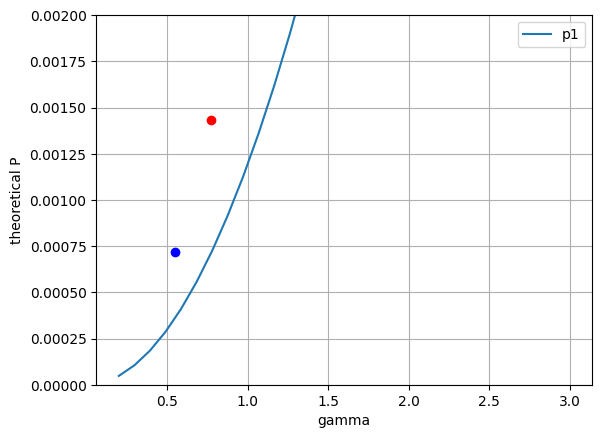

In [7]:
plt.plot(gamma, p1_n,label='p1')
#plt.plot(gamma, p2p_n,label='p2p')
#plt.plot(gamma, p2m_n,label='p2m')
# plt.plot([0.7746, 0.7746, 0.7746], [0.001434, 0.077423, 0.013341], 'ro')
# plt.plot([0.5477, 0.5477, 0.5477], [0.000717, 0.039491, 0.006693], 'bo')
plt.plot([0.7746], [0.001434,], 'ro')
plt.plot([0.5477], [0.000717,], 'bo')
plt.ylim(0.0,0.002)
plt.xlabel('gamma')
plt.ylabel('theoretical P')
plt.legend()
plt.grid()


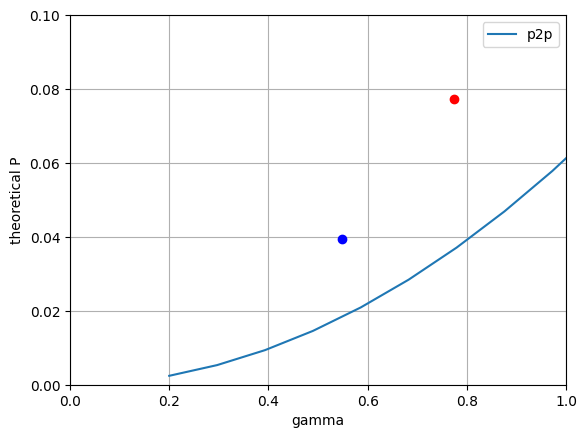

In [8]:
#plt.plot(gamma, p1_n,label='p1')
plt.plot(gamma, p2p_n,label='p2p')
#plt.plot(gamma, p2m_n,label='p2m')
# plt.plot([0.7746, 0.7746, 0.7746], [0.001434, 0.077423, 0.013341], 'ro')
# plt.plot([0.5477, 0.5477, 0.5477], [0.000717, 0.039491, 0.006693], 'bo')
plt.plot([0.7746], [0.077423,], 'ro')
plt.plot([0.5477], [0.039491,], 'bo')
plt.xlabel('gamma')
plt.ylabel('theoretical P')
plt.ylim(0.0,0.1)
plt.xlim(0,0.8)
plt.xlim(0,1)
plt.legend()
plt.grid()

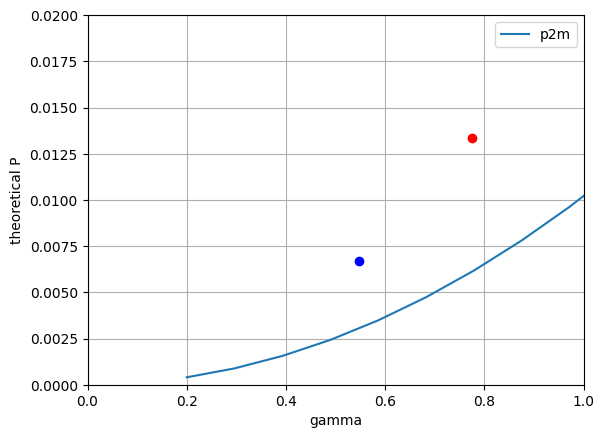

In [9]:
#plt.plot(gamma, p1_n,label='p1')
#plt.plot(gamma, p2p_n,label='p2p')
plt.plot(gamma, p2m_n,label='p2m')
# plt.plot([0.7746, 0.7746, 0.7746], [0.001434, 0.077423, 0.013341], 'ro')
# plt.plot([0.5477, 0.5477, 0.5477], [0.000717, 0.039491, 0.006693], 'bo')
plt.plot([0.7746], [0.013341,], 'ro')
plt.plot([0.5477], [0.006693,], 'bo')
plt.xlabel('gamma')
plt.ylabel('theoretical P')
plt.ylim(0,.02)
plt.xlim(0,1)
plt.legend()
plt.grid()

In [10]:
import sys
# This finds the project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

# --- THIS IS THE LINE YOU ARE MISSING ---
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
# --- ADD THAT LINE! ---

print(f"Project root added to path: {PROJECT_ROOT}")

Project root added to path: /Users/minglu/Documents/Uni/bistable_model_simulation


In [11]:
from simulation.solvers.rate_conversions import calculate_kappas

In [12]:
kappas=calculate_kappas(np.array((1.5,1500,150,25,5.75,25)),750,750,750,np.ones(4)*0.1)

✅ R1 Solver converged.
✅ R2 Solver converged and passed physics checks.

--- Final Intrinsic Rates (Kappa) ---
κ₁⁺ = 7.1757e+02
κ₁⁻ = 1.5000e+03
κ₂⁺ = 4.0292e+04
κ₂⁻ = 6.7154e+03
κ₃⁺ = 5.7500e+00
κ₃⁻ = 2.5000e+01
The estimation is calculated based on the Eq. (32) in Erban's paper.


In [13]:
p_1_emp = 1-np.exp(-kappas[0]*tau)
p_2p_emp = 1-np.exp(-kappas[2]*tau)
p_2m_emp = 1-np.exp(-kappas[3]*tau)

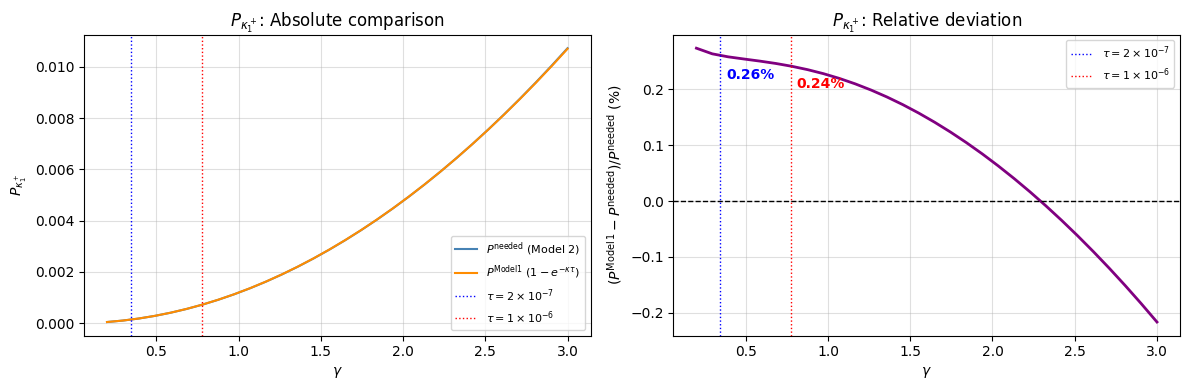

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: absolute comparison (what you have)
axes[0].plot(gamma, p1_n, label=r'$P^{\mathrm{needed}}$ (Model 2)', color='steelblue')
axes[0].plot(gamma, p_1_emp, label=r'$P^{\mathrm{Model 1}}$ ($1-e^{-\kappa\tau}$)', color='darkorange')
axes[0].axvline(0.3464, color='blue', lw=1, ls=':', label=r'$\tau=2\times10^{-7}$')
axes[0].axvline(0.7746, color='red',  lw=1, ls=':', label=r'$\tau=1\times10^{-6}$')
axes[0].set_xlabel(r'$\gamma$')
axes[0].set_ylabel(r'$P_{\kappa_1^+}$')
axes[0].set_title(r'$P_{\kappa_1^+}$: Absolute comparison')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.4)

# Right panel: RELATIVE deviation — this makes the argument compelling!
rel_dev = (p_1_emp - p1_n) / p1_n * 100  # in %
axes[1].plot(gamma, rel_dev, color='purple', lw=2)
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].axvline(0.3464, color='blue', lw=1, ls=':', label=r'$\tau=2\times10^{-7}$')
axes[1].axvline(0.7746, color='red',  lw=1, ls=':', label=r'$\tau=1\times10^{-6}$')

# Annotate the actual % at your operating points
for gv, color, tau_str in [(0.3464, 'blue', r'$\tau=10^{-6}$'), 
                            (0.7746, 'red',  r'$\tau=2\times10^{-6}$')]:
    idx = np.argmin(np.abs(gamma - gv))
    pct = rel_dev[idx]
    axes[1].annotate(f'{pct:.2f}%', 
                     xy=(gv, pct), 
                     xytext=(4, -16),            # 10 points right, 15 points down
                     textcoords='offset points',  # Tells matplotlib to use points, not data units
                     color=color, 
                     fontsize=10, 
                     fontweight='bold')

axes[1].set_xlabel(r'$\gamma$')
axes[1].set_ylabel(r'$(P^{\mathrm{Model\,1}} - P^{\mathrm{needed}}) / P^{\mathrm{needed}}$ (%)')
axes[1].set_title(r'$P_{\kappa_1^+}$: Relative deviation')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.4)

plt.tight_layout()

#plt.savefig('p_lambda_comparison.pdf')'

[ 11.22467534  10.89283253  10.32619062   9.72192183   9.07224651
   8.4083197    7.74146314   7.0710538    6.39034211   5.69040803
   4.96255281   4.19948285   3.39570856   2.54751338   1.65273022
   0.71046101  -0.27919372  -1.31536801  -2.39661997  -3.52108068
  -4.6865691   -5.89067988  -7.13085024  -8.4044113   -9.70862755
 -11.04072767 -12.39792892 -13.77745666 -15.17656038 -16.59252688]


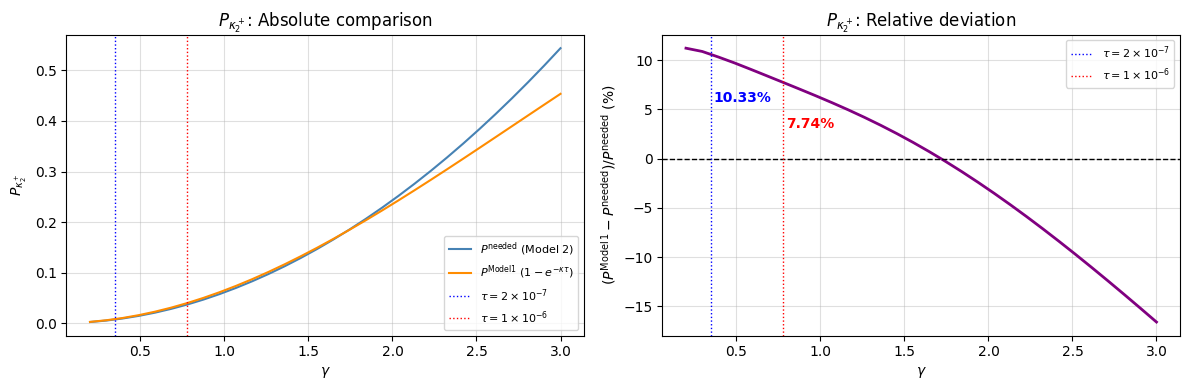

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: absolute comparison (what you have)
axes[0].plot(gamma, p2p_n, label=r'$P^{\mathrm{needed}}$ (Model 2)', color='steelblue')
axes[0].plot(gamma, p_2p_emp, label=r'$P^{\mathrm{Model 1}}$ ($1-e^{-\kappa\tau}$)', color='darkorange')
axes[0].axvline(0.3464, color='blue', lw=1, ls=':', label=r'$\tau=2\times10^{-7}$')
axes[0].axvline(0.7746, color='red',  lw=1, ls=':', label=r'$\tau=1\times10^{-6}$')
axes[0].set_xlabel(r'$\gamma$')
axes[0].set_ylabel(r'$P_{\kappa_2^+}$')
axes[0].set_title(r'$P_{\kappa_2^+}$: Absolute comparison')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.4)

# Right panel: RELATIVE deviation — this makes the argument compelling!
rel_dev = (p_2p_emp - p2p_n) / p2p_n * 100  # in %
axes[1].plot(gamma, rel_dev, color='purple', lw=2)
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].axvline(0.3464, color='blue', lw=1, ls=':', label=r'$\tau=2\times10^{-7}$')
axes[1].axvline(0.7746, color='red',  lw=1, ls=':', label=r'$\tau=1\times10^{-6}$')

# Annotate the actual % at your operating points
for gv, color, tau_str in [(0.3463, 'blue', r'$\tau=2\times 10^{-7}$'), 
                            (0.7746, 'red',  r'$\tau=10^{-6}$')]:
    idx = np.argmin(np.abs(gamma - gv))
    pct = rel_dev[idx]
    axes[1].annotate(f'{pct:.2f}%', xy=(gv, pct), 
                     xytext=(gv+0.02, pct-4.6),
                     color=color, fontsize=10, fontweight='bold')

axes[1].set_xlabel(r'$\gamma$')
axes[1].set_ylabel(r'$(P^{\mathrm{Model\,1}} - P^{\mathrm{needed}}) / P^{\mathrm{needed}}$ (%)')
axes[1].set_title(r'$P_{\kappa_2^+}$: Relative deviation')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.4)

plt.tight_layout()
print(rel_dev)
#plt.savefig('p_lambda_comparison.pdf')

[11.34919805 11.16588552 10.80377499 10.45932822 10.12368387  9.82723956
  9.58061159  9.38240932  9.2249649   9.09823969  8.99220165  8.89801787
  8.8084733   8.71796314  8.62229239  8.51841624  8.40418821  8.27814328
  8.13932296  7.98713963  7.82127378  7.64159775  7.4481196   7.24094225
  7.02023396  6.78620705  6.53910272  6.27918033  6.00670973  5.72196607]


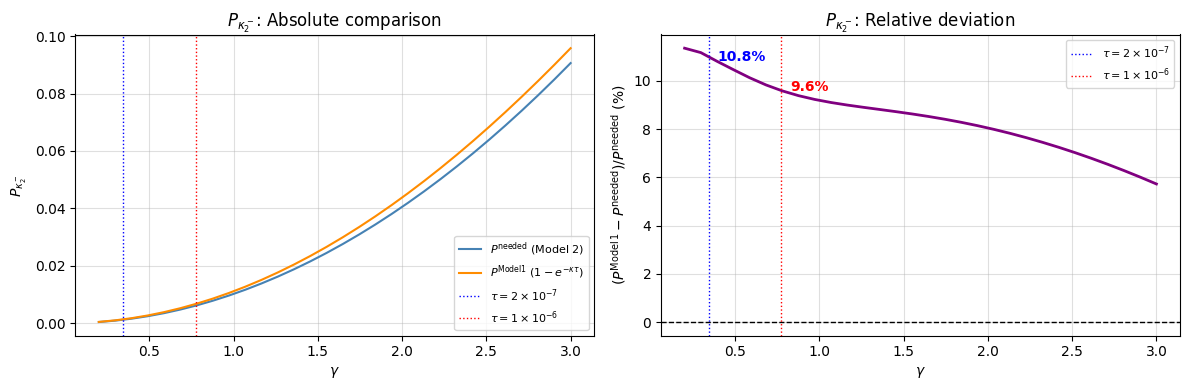

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: absolute comparison (what you have)
axes[0].plot(gamma, p2m_n, label=r'$P^{\mathrm{needed}}$ (Model 2)', color='steelblue')
axes[0].plot(gamma, p_2m_emp, label=r'$P^{\mathrm{Model 1}}$ ($1-e^{-\kappa\tau}$)', color='darkorange')
axes[0].axvline(0.3464, color='blue', lw=1, ls=':', label=r'$\tau=2\times10^{-7}$')
axes[0].axvline(0.7746, color='red',  lw=1, ls=':', label=r'$\tau=1\times10^{-6}$')
axes[0].set_xlabel(r'$\gamma$')
axes[0].set_ylabel(r'$P_{\kappa_2^-}$')
axes[0].set_title(r'$P_{\kappa_2^-}$: Absolute comparison')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.4)

# Right panel: RELATIVE deviation — this makes the argument compelling!
rel_dev = (p_2m_emp - p2m_n) / p2m_n * 100  # in %
axes[1].plot(gamma, rel_dev, color='purple', lw=2)
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].axvline(0.3464, color='blue', lw=1, ls=':', label=r'$\tau=2\times10^{-7}$')
axes[1].axvline(0.7746, color='red',  lw=1, ls=':', label=r'$\tau=1\times10^{-6}$')

# Annotate the actual % at your operating points
for gv, color, tau_str in [(0.3464, 'blue', r'$\tau=2\times 10^{-7}$'), 
                            (0.7746, 'red',  r'$\tau=10^{-6}$')]:
    idx = np.argmin(np.abs(gamma - gv))
    pct = rel_dev[idx]
    axes[1].annotate(f'{pct:.1f}%', xy=(gv, pct), 
                     xytext=(gv+0.05, pct),
                     color=color, fontsize=10, fontweight='bold')

axes[1].set_xlabel(r'$\gamma$')
axes[1].set_ylabel(r'$(P^{\mathrm{Model\,1}} - P^{\mathrm{needed}}) / P^{\mathrm{needed}}$ (%)')
axes[1].set_title(r'$P_{\kappa_2^-}$: Relative deviation')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.4)

plt.tight_layout()
print(rel_dev)
#plt.savefig('p_lambda_comparison.pdf')

p1=1-exp(-kappa*tau)
kappa=-ln(1-p1)/tau

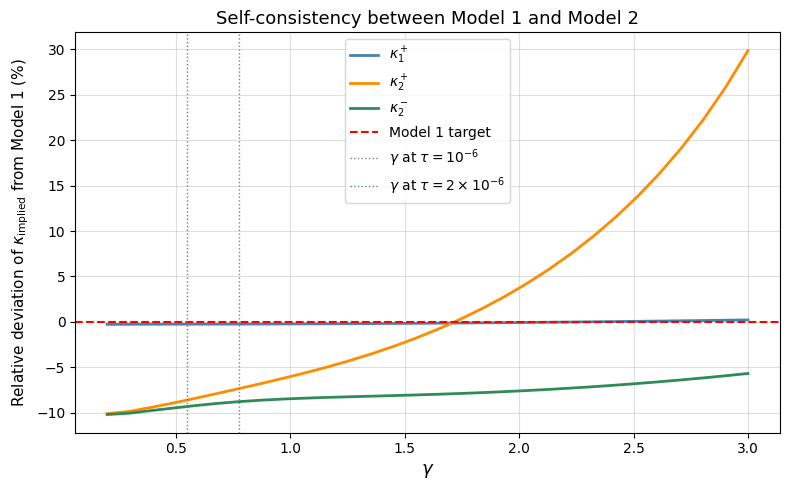

In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

# Compute relative deviations (%)
kappa_model1_vals = [717.57, 40292., 6715.4]  # your red line values
labels   = [r'$\kappa_1^+$', r'$\kappa_2^+$', r'$\kappa_2^-$']
colors   = ['steelblue', 'darkorange', 'seagreen']
p_curves = [p1_n, p2p_n, p2m_n]

for p_n, kappa_ref, label, color in zip(p_curves, kappa_model1_vals, labels, colors):
    kappa_implied = -np.log(1 - p_n) / tau   # tau is your fixed tau
    deviation = (kappa_implied - kappa_ref) / kappa_ref * 100
    ax.plot(gamma, deviation, label=label, color=color, lw=2)

ax.axhline(0, color='red', lw=1.5, linestyle='--', label='Model 1 target')
ax.axvline(0.7746, color='gray', lw=1, linestyle=':', label=r'$\gamma$ at $\tau=10^{-6}$')
ax.axvline(0.5477, color='steelblue', lw=1, linestyle=':', label=r'$\gamma$ at $\tau=2\times10^{-6}$')

ax.set_xlabel(r'$\gamma$', fontsize=13)
ax.set_ylabel(r'Relative deviation of $\kappa_{\mathrm{implied}}$ from Model 1 (%)', fontsize=11)
ax.set_title('Self-consistency between Model 1 and Model 2', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
# plt.savefig('kappa_consistency.pdf', dpi=150)
plt.show()

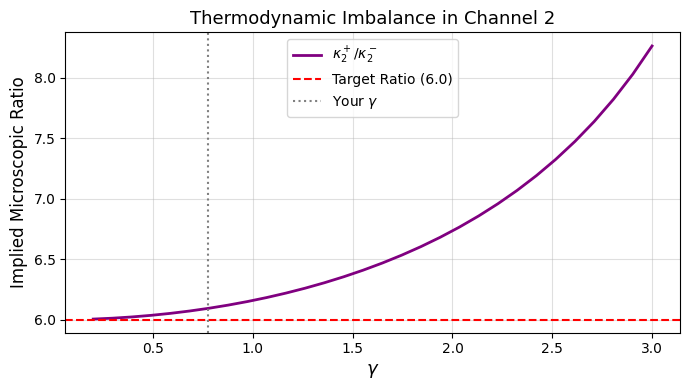

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ratio = (-np.log(1 - p2p_n) / tau) / (-np.log(1 - p2m_n) / tau)

ax.plot(gamma, ratio, color='purple', lw=2, label=r'$\kappa_2^+ / \kappa_2^-$')
ax.axhline(6.0, color='red', linestyle='--', label='Target Ratio (6.0)')
ax.axvline(0.7746, color='gray', linestyle=':', label=r'Your $\gamma$')

ax.set_xlabel(r'$\gamma$', fontsize=13)
ax.set_ylabel(r'Implied Microscopic Ratio', fontsize=12)
ax.set_title('Thermodynamic Imbalance in Channel 2', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()